In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import os
from PIL import Image
import numpy as np
import torch.optim as optim
import random

torch.cuda.empty_cache()


/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/train/n02124075/images/n02124075_82.JPEG


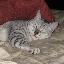

In [28]:
#testing dataset class logic and resizing pf images



root ='/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
#root=root+'/'+mode
root = os.path.join(root, 'train')

folders=[]
with open('/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/wnids.txt') as f:
        for fol_name in f:
            folders.append(fol_name.strip())

image_location=[]

for folder in folders:
    #temp_root=root+folder+'/images'
    temp_root = os.path.join(root, folder, "images")
    for img_file in os.listdir(temp_root):
                if img_file.endswith('.JPEG'):
                    full_path = os.path.join(temp_root, img_file)
                    image_location.append(full_path)

print(image_location[1])

image3= Image.open(image_location[1])
#print(image)
#image = np.array(image) 
#image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
#print(f"Image mode: {image3.mode}")
image3


In [29]:
image1=image3.resize((224,224),Image.BILINEAR)
image = np.array(image1) 
image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
image

tensor([[[0.2745, 0.2745, 0.2784,  ..., 0.0118, 0.0118, 0.0118],
         [0.2745, 0.2745, 0.2784,  ..., 0.0118, 0.0118, 0.0118],
         [0.2863, 0.2863, 0.2902,  ..., 0.0118, 0.0118, 0.0118],
         ...,
         [0.7843, 0.7843, 0.7882,  ..., 0.5216, 0.5137, 0.5137],
         [0.7529, 0.7529, 0.7569,  ..., 0.5020, 0.4941, 0.4941],
         [0.7529, 0.7529, 0.7569,  ..., 0.5020, 0.4941, 0.4941]],

        [[0.0863, 0.0863, 0.0902,  ..., 0.0078, 0.0078, 0.0078],
         [0.0863, 0.0863, 0.0902,  ..., 0.0078, 0.0078, 0.0078],
         [0.0980, 0.0980, 0.1020,  ..., 0.0078, 0.0078, 0.0078],
         ...,
         [0.7333, 0.7333, 0.7373,  ..., 0.4706, 0.4627, 0.4627],
         [0.7020, 0.7020, 0.7059,  ..., 0.4510, 0.4431, 0.4431],
         [0.7020, 0.7020, 0.7059,  ..., 0.4510, 0.4431, 0.4431]],

        [[0.0784, 0.0784, 0.0824,  ..., 0.0275, 0.0275, 0.0275],
         [0.0784, 0.0784, 0.0824,  ..., 0.0275, 0.0275, 0.0275],
         [0.0902, 0.0902, 0.0941,  ..., 0.0275, 0.0275, 0.

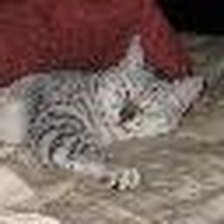

In [30]:
image2=image3.resize((224,224),Image.LANCZOS)
image2

In [31]:

image.shape


torch.Size([3, 224, 224])

In [32]:
#patches logic test
#patching calculation


#224/16=14
#14*14=196
#196*0.75=147 masked patches
#49 unmasked patches
def patchify(img):
    batch,channels,height,weight=img.shape
    patch_size=16
    patchh=height//patch_size
    patchw=weight//patch_size

    x = img.reshape(batch, channels, patchh, patch_size, patchw, patch_size)

    
    x = x.permute(0, 2, 4, 1, 3, 5)

    
    patches = x.reshape(batch, patchh * patchw, channels * patch_size * patch_size)

    return patches

In [33]:
class mydataset(Dataset):

    def __init__(self,mode='train'):
        root ='/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200'
        #root=root+'/'+mode
        root = os.path.join(root, mode)
        
        folders=[]
        with open('/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200/wnids.txt') as f:
                for fol_name in f:
                    folders.append(fol_name.strip())

        self.image_location=[]
        if mode=='train':
            for folder in folders:
                #temp_root=root+folder+'/images'
                temp_root = os.path.join(root, folder, "images")
                for img_file in os.listdir(temp_root):
                            if img_file.endswith('.JPEG'):
                                full_path = os.path.join(temp_root, img_file)
                                self.image_location.append(full_path)
        else:
            temp_root=os.path.join(root,"images")
            for img_file in os.listdir(temp_root):
                            if img_file.endswith('.JPEG'):
                                full_path = os.path.join(temp_root, img_file)
                                self.image_location.append(full_path)
                
    
    def __len__(self):
        return len(self.image_location)

    
    def __getitem__(self,index):
        
        image= Image.open(self.image_location[index]).convert('RGB')
        image=image.resize((224,224),Image.BILINEAR)
        image = np.array(image) 
        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        return image 
    

In [34]:
traindata=mydataset('train')
train_data=DataLoader(traindata,shuffle=True,batch_size=64,pin_memory=True,num_workers=4,drop_last=True)

valdata=mydataset('val')
val_data=DataLoader(valdata,shuffle=False,batch_size=64,pin_memory=True,num_workers=4,drop_last=True)

In [35]:
class mymodel(nn.Module):

    def __init__(self):
        super().__init__()

        ###################################################

        self.encoder_hidden_dimension=768
        self.embedding=nn.Linear(self.encoder_hidden_dimension,self.encoder_hidden_dimension)
        self.patchestotal = 196
        self.positions = nn.Parameter(torch.randn(1, self.patchestotal, self.encoder_hidden_dimension))
        
        
        self.encoderhead=12
        self.no_encoderlayers=12
        
        self.encoderlayer=nn.TransformerEncoderLayer(
            d_model=self.encoder_hidden_dimension,
            nhead=self.encoderhead,
            dim_feedforward=self.encoder_hidden_dimension*3,
            batch_first=True
        )
        
        self.encoder=nn.TransformerEncoder(self.encoderlayer,num_layers=self.no_encoderlayers)

##########################################################
        
        self.mask_token = nn.Parameter(torch.randn(1, 1, self.encoder_hidden_dimension))
        self.decoderhead=6
        self.no_decoderlayer=12
        self.decoder_hidden_dim=384

        self.decoder_embed = nn.Linear(self.encoder_hidden_dimension, self.decoder_hidden_dim)
        
        self.decoderlayer=nn.TransformerDecoderLayer(
            d_model=self.decoder_hidden_dim,
            nhead=self.decoderhead,
            dim_feedforward=self.decoder_hidden_dim*3,
            batch_first=True
        )

        self.decoder=nn.TransformerDecoder(self.decoderlayer,num_layers=self.no_decoderlayer)
        self.decoder_positions = nn.Parameter(torch.randn(1, self.patchestotal, self.decoder_hidden_dim))

        self.output_layer = nn.Linear(self.decoder_hidden_dim, 768)

        self.enco_to_dec_dimension=nn.Linear(self.encoder_hidden_dimension,self.decoder_hidden_dim)



   #*******************************************************************************************************************************************************
    
    def forward(self,image_tensor):
        batch_size=image_tensor.shape[0]
        #print(image_tensor.shape)
        
        patches=patchify(image_tensor)
        patch_embedding=self.embedding(patches)

        patch_embedding=patch_embedding+self.positions

        
        unmask_indices = torch.tensor(random.sample(range(196), 49),device=image_tensor.device)
        unmask_patches = patch_embedding[:,unmask_indices,:]

        encoderoutput=self.encoder(unmask_patches)

        mask_indices=[]
        for i in range(196):
            if i not in unmask_indices:
                mask_indices.append(i)

        mask_indices_tensor=torch.tensor(mask_indices,device=image_tensor.device)
        
        mask_tokens = self.mask_token.expand(batch_size, 196-49, self.encoder_hidden_dimension)

        decoder_input = torch.zeros(batch_size, 196, 768, device=image_tensor.device)
        decoder_input[:, unmask_indices, :] = encoderoutput
        
        encoderoutput=self.enco_to_dec_dimension(encoderoutput)
        decoder_input[:, mask_indices, :] = mask_tokens

        
        decoder_input=self.decoder_embed(decoder_input)
        
        decoder_input=decoder_input+self.decoder_positions
        decoder_output = self.decoder(
            tgt=decoder_input,  
            memory=encoderoutput  
        )

        reconstruction = self.output_layer(decoder_output)  # (B, N, patch_dim)

        return reconstruction,mask_indices_tensor, unmask_indices
        

        
    

In [36]:
random_indices = torch.tensor(random.sample(range(196), 49))
random_indices
#selected_patches = patches[random_indices]

tensor([181,  37, 122, 117, 165, 178, 102,  36,  22, 157, 179, 144, 188, 162,
         53,  25,  52, 189,  32,  57,  34,  13, 124, 191,  98, 116, 192,  40,
         16,  42,  80, 141, 118,  17, 171, 180, 176, 187, 182, 167, 150, 184,
         59,  83,   6,  18,  99,  46, 126])

In [37]:
mymodel=mymodel()


mymodel = torch.nn.DataParallel(mymodel)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mymodel.to(device)

epochs=8

lossfunction=nn.MSELoss()

optimizer = torch.optim.AdamW(mymodel.parameters(),lr=1.5e-4,betas=(0.9, 0.95),weight_decay=0.05)

In [38]:
train_loss=[]
val_loss=[]


In [39]:
print("Training start")
for epoch in range(epochs):
    mymodel.train()
    totalloss=0
    for images in train_data:
        
        images =images.to(device)


        optimizer.zero_grad()
        
        results,maskedpatchslist,unmask_indices = mymodel(images)
        original_patches=patchify(images)

        masked_output=results[:,maskedpatchslist,:]
        original=original_patches[:, maskedpatchslist, :]
        
        loss=lossfunction(masked_output,original)

        
        loss.backward()
        optimizer.step()
        totalloss+=loss.item()
        
    avgloss = totalloss / len(train_data)
    train_loss.append(avgloss)


    mymodel.eval()
    total_valloss=0
    with torch.no_grad():
        for valimages in val_data:
            valimages= valimages.to(device)

            optimizer.zero_grad()
            result,maskedpatchslist,unmask_indices = mymodel(valimages)

            original_patches = patchify(valimages)

            masked_output=result[:,maskedpatchslist,:]
            original=original_patches[:, maskedpatchslist, :]
        
            valloss=lossfunction(masked_output,original)
            #valloss=lossfunction(original,new_maskedpatches)
    
            
            
            total_valloss+=valloss.item()
            
    avg_valloss = total_valloss / len(val_data)
    val_loss.append(avg_valloss)
    
    if (epoch + 1) % 3 == 0:
        torch.save({
            'epoch': epoch,
            'model_state_dict': mymodel.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
        }, f'checkpoint_epoch_{epoch+1}.pt')
        print(f"Model saved at epoch {epoch+1}")

    print(f"Epoch {epoch+1}, Train Loss: {avgloss:.4f}, Val Loss: {avg_valloss:.4f}")


    

Training start
Epoch 1, Train Loss: 0.0738, Val Loss: 0.0713
Epoch 2, Train Loss: 0.0707, Val Loss: 0.0708
Model saved at epoch 3
Epoch 3, Train Loss: 0.0706, Val Loss: 0.0710
Epoch 4, Train Loss: 0.0706, Val Loss: 0.0712
Epoch 5, Train Loss: 0.0705, Val Loss: 0.0702
Model saved at epoch 6
Epoch 6, Train Loss: 0.0700, Val Loss: 0.0703
Epoch 7, Train Loss: 0.0700, Val Loss: 0.0701
Epoch 8, Train Loss: 0.0699, Val Loss: 0.0702


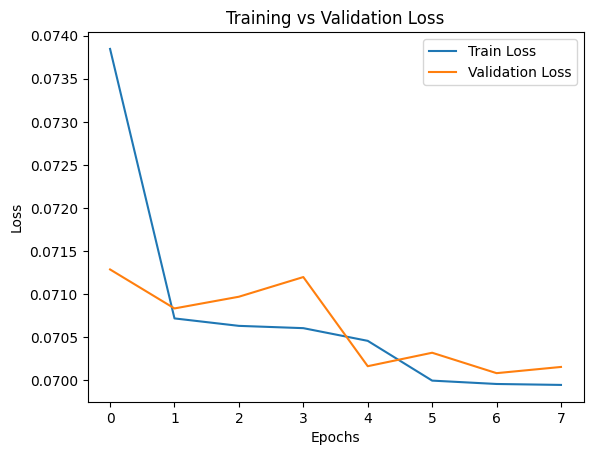

In [42]:
import matplotlib.pyplot as plt

plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()


In [4]:
# Suppose 'model' is your trained PyTorch model

# 1️⃣ Save only weights (recommended)
torch.save(mymodel.state_dict(), "model.pth")

# 2️⃣ Save entire model (quick demo)
#torch.save(model, "model5.pt")


NameError: name 'mymodel' is not defined